# DEtection TRansformer（DETR）目标检测模型

> **论文**：*End-to-End Object Detection with Transformers*（Carion et al., Facebook AI Research, 2020）
>
> **核心思想**：将目标检测建模为**集合预测**问题，以 Transformer 编解码器配合可学习的目标查询（Object Queries），端到端完成边界框回归与类别分类，彻底摆脱 Anchor 设计与 NMS 后处理。
>
> **创新特性**：首个纯 Transformer 端到端目标检测器，结构简洁统一，在 COCO 基准上与 Faster R-CNN 性能持平，并在**大目标检测**上表现更优。

> ### Object Query 各层次 Shape 说明
>
> | 层次 | Shape | 含义 |
> |------|-------|------|
> | 单个查询 | `(256,)` | 一个 object query，`hidden_dim=256` 维可学习向量 |
> | 全部查询（无 batch） | `(100, 256)` | 100 个查询，`nn.Parameter` 的原始形状 |
> | 全部查询（有 batch） | `(N, 100, 256)` | 送入 Transformer Decoder 时，通过 `.unsqueeze(0)` 扩展 batch 维 |
> | Decoder 输出 | `(N, 100, 256)` | 每个查询经 Decoder 处理后得到的上下文特征向量 |

## 一、环境准备与骨干网络预览

In [4]:
import torch                              # 导入 PyTorch 深度学习框架，提供张量运算与自动微分能力
from torch import nn                     # 从 torch 导入神经网络模块 nn，包含 Linear、Conv2d 等层
from torchvision.models import resnet50  # 从 torchvision 导入 ResNet-50 预训练模型构造函数

# 查看 ResNet-50 的倒数第二个子模块
# list(...children()): 将模型拆解为按顺序排列的子模块列表，类型为 List[nn.Module]
# [-2]: 取列表中倒数第二个元素，即 AdaptiveAvgPool2d(output_size=(1, 1))
# 目的：了解骨干网络末尾结构，DETR 会去掉最后两层（AdaptiveAvgPool2d + 全连接层）
print(list(resnet50(weights='IMAGENET1K_V2').children())[-2])

AdaptiveAvgPool2d(output_size=(1, 1))


## 二、DETR 模型架构定义与推理测试

>  ### `nn.Transformer`
> PyTorch 提供的完整 Transformer 模块，内部封装了一个 **Encoder** 和一个 **Decoder**，直接接受源序列与目标序列，完成编解码全流程。
>
> ⚠️ **不含 Embedding**：`nn.Transformer` 本身不包含任何词嵌入或位置编码，输入必须是已经完成嵌入的浮点张量。使用者需要在外部自行完成 Token Embedding 和 Positional Encoding，再将结果送入模型。
>
> **构造参数：**
> <table><tr><th>参数</th><th>含义</th></tr>
> <tr><td><code>d_model</code></td><td>特征维度（即 Embedding 维度），默认 512</td></tr>
> <tr><td><code>nhead</code></td><td>多头注意力的头数，默认 8</td></tr>
> <tr><td><code>num_encoder_layers</code></td><td>Encoder 堆叠层数，默认 6</td></tr>
> <tr><td><code>num_decoder_layers</code></td><td>Decoder 堆叠层数，默认 6</td></tr>
> <tr><td><code>dim_feedforward</code></td><td>FFN 中间层维度，默认 2048</td></tr>
> <tr><td><code>dropout</code></td><td>Dropout 概率，默认 0.1</td></tr>
> <tr><td><code>batch_first</code></td><td>为 <code>True</code> 时输入形状为 <code>(N, S, E)</code>，默认 <code>False</code> 即 <code>(S, N, E)</code></td></tr></table>
>
> **`forward()` 掩码参数：**
> <table><tr><th>参数</th><th>形状</th><th>作用</th></tr>
> <tr><td><code>src_mask</code></td><td><code>(S, S)</code> 或 <code>(N·nhead, S, S)</code></td><td>Encoder 自注意力掩码，float 或 bool</td></tr>
> <tr><td><code>tgt_mask</code></td><td><code>(T, T)</code> 或 <code>(N·nhead, T, T)</code></td><td>Decoder 自注意力掩码，float 或 bool，自回归时传因果掩码</td></tr>
> <tr><td><code>memory_mask</code></td><td><code>(T, S)</code></td><td>Decoder 交叉注意力掩码，float 或 bool</td></tr>
> <tr><td><code>src_key_padding_mask</code></td><td><code>(N, S)</code></td><td>Encoder padding 掩码，bool</td></tr>
> <tr><td><code>tgt_key_padding_mask</code></td><td><code>(N, T)</code></td><td>Decoder 输入 padding 掩码，bool</td></tr>
> <tr><td><code>memory_key_padding_mask</code></td><td><code>(N, S)</code></td><td>Encoder 输出在 Decoder 端的 padding 掩码，bool</td></tr>
> <tr><td><code>src_is_causal</code></td><td>bool</td><td>提示 <code>src_mask</code> 是因果掩码，由模块自动生成，无需手动构造</td></tr>
> <tr><td><code>tgt_is_causal</code></td><td>bool</td><td>提示 <code>tgt_mask</code> 是因果掩码，常用于自回归解码</td></tr>
> <tr><td><code>memory_is_causal</code></td><td>bool</td><td>提示 <code>memory_mask</code> 是因果掩码，默认 <code>False</code></td></tr></table>
>
> **掩码类型说明：**
> - **float 掩码**（`_mask` 系列）：直接加到注意力分数上，屏蔽位置填 `-inf`，softmax 后权重趋近 0
> - **bool 掩码**（`_mask` 和 `_key_padding_mask` 均支持）：`True` = 禁止参与注意力，`False` = 保留
> - ⚠️ **注意**：bool 类型的 `_mask` 参数中 `True` 表示**忽略**，这与 `F.scaled_dot_product_attention` 中 `attn_mask` 的 bool 定义**相反**
>
> **输入输出（`batch_first=True`）：**
> - `src`：`(N, S, d_model)` — 已嵌入的源序列（Encoder 输入）
> - `tgt`：`(N, T, d_model)` — 已嵌入的目标序列（Decoder 输入）
> - 输出：`(N, T, d_model)` — Decoder 每个位置的上下文特征
>
> **使用示例（NLP 机器翻译）：**
>
> ```python
> import torch
> from torch import nn
>
> # 构建完整的 Encoder-Decoder Transformer（batch_first=True 时 shape 为 (N, S, E)）
> transformer = nn.Transformer(d_model=512, nhead=8, batch_first=True)
>
> N, S, T, E = 2, 10, 7, 512                                    # N=batch, S=源序列长, T=目标序列长, E=特征维度
> src = torch.rand(N, S, E)                                      # 已嵌入的源序列，shape (2, 10, 512)
> tgt = torch.rand(N, T, E)                                      # 已嵌入的目标序列，shape (2, 7, 512)
>
> # ── 掩码构造 ──────────────────────────────────────────────────
> # 因果掩码（上三角填 -inf）：训练时防止 Decoder 在第 t 步看到 t+1 及之后的 token
> tgt_mask = nn.Transformer.generate_square_subsequent_mask(T)   # shape (T, T) = (7, 7)
>
> # padding 掩码（bool）：True = 该位置是 padding，不参与注意力计算
> src_key_padding_mask = torch.zeros(N, S, dtype=torch.bool)     # shape (N, S) = (2, 10)
> src_key_padding_mask[0, 8:] = True                             # 第 0 个样本末尾 2 个位置是 padding
> tgt_key_padding_mask = torch.zeros(N, T, dtype=torch.bool)     # shape (N, T) = (2, 7)
> tgt_key_padding_mask[0, 6:] = True                             # 第 0 个样本最后 1 个目标 token 是 padding
>
> # ── forward ───────────────────────────────────────────────────
> out = transformer(
>     src,
>     tgt,
>     tgt_mask=tgt_mask,                                         # Decoder 自注意力因果掩码，shape (T, T)
>     src_key_padding_mask=src_key_padding_mask,                 # Encoder padding 掩码，shape (N, S)
>     tgt_key_padding_mask=tgt_key_padding_mask,                 # Decoder 输入 padding 掩码，shape (N, T)
>     memory_key_padding_mask=src_key_padding_mask,              # Encoder 输出在 Decoder 端的 padding 掩码，与 src 一致
> )                                                              # → shape (N, T, d_model) = (2, 7, 512)
> print(out.shape)                                               # → torch.Size([2, 7, 512])
> ```

> ### `nn.TransformerEncoder`
> 单独的 Encoder 模块，由 `num_layers` 个 `TransformerEncoderLayer` 堆叠而成。每一层包含：**多头自注意力（Self-Attention）→ FFN**，附带残差连接与 LayerNorm。
>
> ⚠️ **不含 Embedding**：同样不负责嵌入，输入须为已加入位置编码的特征张量。
>
> **构造方式：**
>
> ```python
> from torch import nn
>
> # Step 1：定义单层 EncoderLayer（包含自注意力 + FFN）
> encoder_layer = nn.TransformerEncoderLayer(d_model=256, nhead=8, batch_first=True)
>
> # Step 2：将多个 EncoderLayer 堆叠成完整 Encoder
> encoder = nn.TransformerEncoder(encoder_layer, num_layers=6)
> ```
>
> **`forward()` 掩码参数：**
> <table><tr><th>参数</th><th>形状</th><th>作用</th></tr>
> <tr><td><code>mask</code></td><td><code>(S, S)</code> 或 <code>(N·nhead, S, S)</code></td><td>自注意力掩码（float 或 bool），控制 token 间可见关系</td></tr>
> <tr><td><code>src_key_padding_mask</code></td><td><code>(N, S)</code></td><td>padding 掩码（bool），<code>True</code> = 忽略该位置</td></tr>
> <tr><td><code>is_causal</code></td><td>bool</td><td>提示 <code>mask</code> 是因果掩码，由模块自动生成，默认 <code>None</code>（自动推断）</td></tr></table>
>
> **使用示例（NLP 变长序列）：**
>
> ```python
> import torch
> from torch import nn
>
> encoder_layer = nn.TransformerEncoderLayer(d_model=256, nhead=8, batch_first=True)
> encoder       = nn.TransformerEncoder(encoder_layer, num_layers=6)
>
> N, S, E = 2, 15, 256                                   # N=batch, S=序列长度, E=特征维度
> src = torch.rand(N, S, E)                              # 已加入位置编码的特征，shape (2, 15, 256)
>
> # padding 掩码：True = 该位置是 padding 需要被忽略，False = 真实 token 保留
> src_key_padding_mask = torch.zeros(N, S, dtype=torch.bool)  # shape (2, 15)，初始全 False
> src_key_padding_mask[0, 12:] = True                    # 第 0 个样本末尾 3 个位置为 padding
>
> out = encoder(src, src_key_padding_mask=src_key_padding_mask)  # shape (N, S, d_model)
> print(out.shape)                                       # → torch.Size([2, 15, 256])
> ```

> ### `nn.TransformerDecoder`
> 单独的 Decoder 模块，由 `num_layers` 个 `TransformerDecoderLayer` 堆叠而成。每一层包含：**自注意力 → 交叉注意力（Cross-Attention，与 Encoder 输出交互）→ FFN**，同样附带残差连接与 LayerNorm。
>
> ⚠️ **不含 Embedding**：`tgt` 需要在外部完成嵌入后再传入。
>
> **构造方式：**
>
> ```python
> from torch import nn
>
> # Step 1：定义单层 DecoderLayer（包含自注意力 + 交叉注意力 + FFN）
> decoder_layer = nn.TransformerDecoderLayer(d_model=256, nhead=8, batch_first=True)
>
> # Step 2：将多个 DecoderLayer 堆叠成完整 Decoder
> decoder = nn.TransformerDecoder(decoder_layer, num_layers=6)
> ```
>
> **`forward()` 掩码参数：**
> <table><tr><th>参数</th><th>形状</th><th>作用</th></tr>
> <tr><td><code>tgt_mask</code></td><td><code>(T, T)</code> 或 <code>(N·nhead, T, T)</code></td><td>Decoder 自注意力掩码（float 或 bool），自回归时传因果掩码</td></tr>
> <tr><td><code>memory_mask</code></td><td><code>(T, S)</code></td><td>交叉注意力掩码（float 或 bool），控制 query 能关注 Encoder 的哪些位置</td></tr>
> <tr><td><code>tgt_key_padding_mask</code></td><td><code>(N, T)</code></td><td>Decoder 输入 padding 掩码（bool）</td></tr>
> <tr><td><code>memory_key_padding_mask</code></td><td><code>(N, S)</code></td><td>Encoder 输出的 padding 掩码（bool），与 Encoder 端保持一致</td></tr>
> <tr><td><code>tgt_is_causal</code></td><td>bool</td><td>提示 <code>tgt_mask</code> 是因果掩码，默认 <code>None</code>（自动推断）</td></tr>
> <tr><td><code>memory_is_causal</code></td><td>bool</td><td>提示 <code>memory_mask</code> 是因果掩码，默认 <code>False</code></td></tr></table>
>
> **使用示例（NLP 自回归解码）：**
>
> ```python
> import torch
> from torch import nn
>
> decoder_layer = nn.TransformerDecoderLayer(d_model=256, nhead=8, batch_first=True)
> decoder       = nn.TransformerDecoder(decoder_layer, num_layers=6)
>
> N, S, T, E = 2, 15, 10, 256                              # N=batch, S=源序列长, T=目标序列长
> memory = torch.rand(N, S, E)                             # Encoder 输出，shape (2, 15, 256)
> tgt    = torch.rand(N, T, E)                             # 目标序列嵌入，shape (2, 10, 256)
>
> # 因果掩码（上三角为 -inf），防止 Decoder 在第 t 步看到 t+1 及之后的 token
> tgt_mask = nn.Transformer.generate_square_subsequent_mask(T)  # shape (T, T) = (10, 10)
>
> out = decoder(tgt, memory, tgt_mask=tgt_mask)            # shape (N, T, d_model)
> print(out.shape)                                         # → torch.Size([2, 10, 256])
> ```

In [1]:
import torch                              # 导入 PyTorch 深度学习框架
from torch import nn                     # 导入神经网络模块，提供 Module、Linear、Conv2d 等基础组件
from torchvision.models import resnet50  # 导入 ResNet-50 预训练模型，用作视觉骨干网络


class DETR(nn.Module):
    """
    DETR（DEtection TRansformer）目标检测模型。

    将 CNN 骨干提取的特征输入 Transformer，利用可学习目标查询（object queries）
    直接并行预测所有目标的类别和边界框，无需锚框（anchor）与非极大值抑制（NMS）。

    Args:
        num_classes (int): 目标类别数（不含背景），如 COCO 为 91。
        hidden_dim (int): Transformer 的隐层维度（embedding 维度），如 256。
        nheads (int): 多头注意力的头数，如 8。
        num_encoder_layers (int): Transformer Encoder 的堆叠层数，如 6。
        num_decoder_layers (int): Transformer Decoder 的堆叠层数，如 6。
    """

    def __init__(self, num_classes, hidden_dim, nheads,
                 num_encoder_layers, num_decoder_layers):
        super().__init__()  # 调用 nn.Module 基类的 __init__，完成模块的基础注册

        # 骨干网络：取 ResNet-50 除最后两层之外的所有子模块
        # list(...children())[:-2]: 去除末尾的 AdaptiveAvgPool2d 和全连接层 fc
        # nn.Sequential(*...): 将子模块列表打包成顺序执行的网络
        # 输入: (N, 3, H, W)  →  输出: (N, 2048, H/32, W/32)
        self.backbone = nn.Sequential(
            *list(resnet50(weights='IMAGENET1K_V2').children())[:-2]
        )

        # 投影层：1×1 卷积将骨干输出通道数从 2048 压缩至 hidden_dim（如 256）
        # kernel_size=1: 不改变空间尺寸，仅做通道维度的线性变换（等价于逐像素全连接）
        # 输入: (N, 2048, H/32, W/32)  →  输出: (N, hidden_dim, H/32, W/32)
        self.conv = nn.Conv2d(2048, hidden_dim, 1)

        # Transformer 模块：包含 Encoder 和 Decoder 两部分
        # hidden_dim: 模型维度（d_model）；nheads: 多头注意力头数
        # num_encoder_layers / num_decoder_layers: 编解码器各自的堆叠层数
        # batch_first=True: 输入/输出张量维度顺序为 (batch, seq, feature)
        self.transformer = nn.Transformer(
            hidden_dim, nheads,
            num_encoder_layers, num_decoder_layers,
            batch_first=True
        )

        # 分类头：将 Decoder 每个输出向量映射为 (num_classes+1) 维 logit
        # +1 表示额外的"背景"类别（索引 num_classes）
        # 输入: (N, num_queries, hidden_dim)  →  输出: (N, num_queries, num_classes+1)
        self.linear_class = nn.Linear(hidden_dim, num_classes + 1)

        # 边界框回归头：将 Decoder 每个输出向量映射为 4 维坐标 (cx, cy, w, h)
        # 输入: (N, num_queries, hidden_dim)  →  输出: (N, num_queries, 4)
        self.linear_bbox = nn.Linear(hidden_dim, 4)

        # 目标查询位置嵌入（object queries）：可学习参数，随机初始化
        # 形状: (100, hidden_dim)；100 表示最多同时预测 100 个目标
        # 作为 Decoder 的目标序列（tgt）输入，每个向量负责检测一个目标
        self.query_pos = nn.Parameter(torch.rand(100, hidden_dim))

        # 行位置嵌入：对特征图高度方向编码，形状 (50, hidden_dim//2)
        # 50 可覆盖 H/32 最大达 50 的特征图行数（图像高度 ≤ 1600）
        self.row_embed = nn.Parameter(torch.rand(50, hidden_dim // 2))

        # 列位置嵌入：对特征图宽度方向编码，形状 (50, hidden_dim//2)
        # 与行嵌入拼接后构成完整的二维空间位置编码
        self.col_embed = nn.Parameter(torch.rand(50, hidden_dim // 2))

    def forward(self, inputs):
        """
        前向传播：从原始图像输出类别预测与边界框预测。

        Args:
            inputs (torch.Tensor): 输入图像，形状为 (N, 3, H, W)。

        Returns:
            Tuple[torch.Tensor, torch.Tensor]:
                - logits: 类别预测 logits，形状 (N, num_queries, num_classes+1)。
                - bboxes: 边界框预测坐标，形状 (N, num_queries, 4)。
        """
        # 骨干网络特征提取：图像经 32 倍下采样，通道扩展至 2048
        # 输入: (N, 3, H, W)  →  输出: (N, 2048, H/32, W/32)，如 (1, 2048, 25, 38)
        x = self.backbone(inputs)
        print(f'Retnet-50 backbone(骨干网络)输出的特征图的shape: {x.shape}')

        # 1×1 卷积降维：将通道数从 2048 压缩到 hidden_dim
        # 输入: (N, 2048, H/32, W/32)  →  输出: (N, hidden_dim, H/32, W/32)，如 (1, 256, 25, 38)
        h = self.conv(x)
        print(f'h.shape---{h.shape}')

        # 取特征图的空间尺寸 H（行数）和 W（列数），均为 int
        H, W = h.shape[-2:]

        # 构建二维空间位置编码（将行列嵌入拼接）
        # self.col_embed[:W]: 取前 W 个列嵌入，形状 (W, hidden_dim//2)
        #   .unsqueeze(0): 增加行维度，形状 (1, W, hidden_dim//2)
        #   .repeat(H, 1, 1): 沿行方向复制 H 次，形状 (H, W, hidden_dim//2)
        # self.row_embed[:H]: 取前 H 个行嵌入，形状 (H, hidden_dim//2)
        #   .unsqueeze(1): 增加列维度，形状 (H, 1, hidden_dim//2)
        #   .repeat(1, W, 1): 沿列方向复制 W 次，形状 (H, W, hidden_dim//2)
        # torch.cat([...], dim=-1): 在最后维拼接列编码和行编码，形状 (H, W, hidden_dim)
        pos = torch.cat([
            self.col_embed[:W].unsqueeze(0).repeat(H, 1, 1),  # (H, W, hidden_dim//2)
            self.row_embed[:H].unsqueeze(1).repeat(1, W, 1),  # (H, W, hidden_dim//2)
        ], dim=-1)
        print(pos.shape)  # 验证位置编码形状：(H, W, hidden_dim)，如 (25, 38, 256)

        # 将位置编码展平为序列并增加 batch 维度
        # .flatten(0, 1): 合并前两维 (H, W) → 序列长度 H*W，形状 (H*W, hidden_dim)
        # .unsqueeze(0): 增加 batch 维度，形状 (1, H*W, hidden_dim)，如 (1, 950, 256)
        pos = pos.flatten(0, 1).unsqueeze(0)
        print(f'pos.shape  {pos.shape}')  # 验证：(1, H*W, hidden_dim)，如 (1, 950, 256)

        # Transformer 前向传播
        # ── Encoder 输入 (src) ──
        #   h.flatten(2): 将 h 最后两维 (H/32, W/32) 展平，形状 (N, hidden_dim, H*W)
        #   .permute(0, 2, 1): 调换维度为 batch_first 格式，形状 (N, H*W, hidden_dim)
        #   pos + ...: 与位置编码相加，形状 (N, H*W, hidden_dim)
        # ── Decoder 输入 (tgt) ──
        #   self.query_pos.unsqueeze(0): 增加 batch 维度，形状 (1, 100, hidden_dim)
        # ── 输出 ──
        #   h: Decoder 输出，形状 (N, 100, hidden_dim)
        h = self.transformer(
            pos + h.flatten(2).permute(0, 2, 1),  # Encoder 源序列: (N, H*W, hidden_dim)
            self.query_pos.unsqueeze(0)            # Decoder 目标查询: (1, 100, hidden_dim)
        )
        print(f'输出尺寸：{h.shape}')  # 验证 Transformer 输出：(N, 100, hidden_dim)，如 (1, 100, 256)

        # 分类头：每个 query 对应 (num_classes+1) 个 logit，形状 (N, 100, num_classes+1)
        # 边界框头：每个 query 对应 4 维坐标 (cx, cy, w, h)，形状 (N, 100, 4)
        return self.linear_class(h), self.linear_bbox(h)


# 实例化 DETR：91 类（COCO 数据集）+ 1 背景，隐层 256 维，8 头注意力，6 层编解码器
detr = DETR(
    num_classes=91,        # COCO 数据集共 91 个目标类别
    hidden_dim=256,        # Transformer 隐层维度 d_model=256
    nheads=8,              # 多头注意力的头数
    num_encoder_layers=6,  # Encoder 堆叠 6 层
    num_decoder_layers=6   # Decoder 堆叠 6 层
)
detr.eval()  # 切换评估模式：关闭 Dropout，固定 BatchNorm 统计量

# 构造模拟输入：batch_size=1，RGB 图像，高 800 宽 1200
# 形状: (N, C, H, W) = (1, 3, 800, 1200)
inputs = torch.randn(1, 3, 800, 1200)

# 前向推理，得到类别 logits 和边界框坐标
# logits 形状: (1, 100, 92)；bboxes 形状: (1, 100, 4)
logits, bboxes = detr(inputs)
logits.shape, bboxes.shape  # 查看两个输出张量的维度形状

Retnet-50 backbone(骨干网络)输出的特征图的shape: torch.Size([1, 2048, 25, 38])
h.shape---torch.Size([1, 256, 25, 38])
torch.Size([25, 38, 256])
pos.shape  torch.Size([1, 950, 256])
输出尺寸：torch.Size([1, 100, 256])


(torch.Size([1, 100, 92]), torch.Size([1, 100, 4]))

## 三、特征图尺寸辅助计算

In [5]:
# 计算骨干网络输出特征图展平后的序列长度
# 输入图像 800×1200，经 ResNet-50 下采样 32 倍后特征图尺寸为 25×38
# 展平为一维序列后长度为 25*38=950，即 Transformer Encoder 的输入序列长度
25 * 38

950

In [2]:
# 计算另一分辨率场景下特征图展平后的序列长度
# 若特征图尺寸为 80×14（如更高分辨率图像的情形），展平序列长度为 80*14=1120
80 * 14

1120

## 四、Hugging Face DETR 推理实验

### 4.1 加载预训练模型与图像处理器

In [1]:
import os                                                              # 操作系统接口，用于设置环境变量
from PIL import Image                                                  # PIL 图像库，用于打开和处理图像
import requests                                                        # HTTP 请求库，用于从 URL 下载测试图像
import torch                                                           # PyTorch 框架，提供推理所需的张量与 no_grad 上下文
import matplotlib.pyplot as plt                                        # Matplotlib 绘图，用于渲染检测结果图
import matplotlib.patches as patches                                   # Matplotlib patches，提供矩形框绘制
from huggingface_hub import snapshot_download                          # HF Hub 文件下载工具，返回本地缓存目录路径 str
from transformers import DetrImageProcessor, DetrForObjectDetection    # HF Transformers DETR 组件

# 设置 HF 国内镜像站，snapshot_download 和 from_pretrained 均会自动使用该地址
os.environ["HF_ENDPOINT"] = "https://hf-mirror.com"  # str，hf-mirror.com 为 HuggingFace 国内镜像

MODEL_NAME = "facebook/detr-resnet-50"  # str，HuggingFace 模型 id，使用默认主分支（依赖 timm 提供 ResNet backbone）

# ─── 步骤 1：下载模型文件到本地 ────────────────────────────────────────────────
# snapshot_download 默认使用 cache_dir + 符号链接（symlink）组织文件结构
# 但 Windows 下创建符号链接需要管理员权限或开启开发者模式，否则报 WinError 1314
# 解决方案：改用 local_dir 参数——文件直接复制到指定目录，不创建符号链接
#
# 参数 repo_id:   str，模型 id
# 参数 local_dir: str，文件直接下载到此目录（无符号链接），Windows 下无需额外权限
#                 若目录已存在且文件完整则跳过下载
# 返回值: str，等于 local_dir 的绝对路径
MODEL_LOCAL_DIR = "./model_cache/detr-resnet-50"  # str，模型文件的本地存储目录
model_dir = snapshot_download(
    repo_id=MODEL_NAME,
    local_dir=MODEL_LOCAL_DIR
)
print(f"模型本地路径: {model_dir}")

# ─── 步骤 2：从本地目录加载模型 ──────────────────────────────────────────────────
# DetrImageProcessor.from_pretrained: 从本地目录加载处理器配置（无需联网）
# 返回 DetrImageProcessor 实例，负责图像缩放、归一化和 BatchFeature 打包
processor = DetrImageProcessor.from_pretrained(model_dir)

# DetrForObjectDetection.from_pretrained: 从本地目录加载权重（无需联网）
# 返回 DetrForObjectDetection 实例，内部包含：
#   - backbone: timm ResNet-50，提取多尺度特征图
#   - transformer: 6 层 Encoder + 6 层 Decoder，d_model=256，nhead=8
#   - class_labels_classifier: Linear(256, 92)，输出 91+1 类 logit
#   - bbox_predictor: MLP → 4 维归一化坐标 (cx, cy, w, h)
model = DetrForObjectDetection.from_pretrained(model_dir)
model.eval()  # 切换评估模式：关闭 Dropout，停止 BN 统计量更新

# 统计并打印模型总参数量（所有权重张量元素数之和），类型为 int
total_params = sum(p.numel() for p in model.parameters())
print(f"模型加载成功，共 {total_params:,} 个参数")

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 6 files:   0%|          | 0/6 [00:00<?, ?it/s]

模型本地路径: C:\Users\15513\Desktop\ObjectDetectionPractice\model_cache\detr-resnet-50


Loading weights:   0%|          | 0/530 [00:00<?, ?it/s]

[transformers] DetrForObjectDetection LOAD REPORT from: C:\Users\15513\Desktop\ObjectDetectionPractice\model_cache\detr-resnet-50
Key                                                            | Status     |  | 
---------------------------------------------------------------+------------+--+-
model.backbone.model.layer4.0.downsample.1.num_batches_tracked | UNEXPECTED |  | 
model.backbone.model.layer2.0.downsample.1.num_batches_tracked | UNEXPECTED |  | 
model.backbone.model.layer3.0.downsample.1.num_batches_tracked | UNEXPECTED |  | 
model.backbone.model.layer1.0.downsample.1.num_batches_tracked | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


模型加载成功，共 41,524,768 个参数


### 4.2 图像预处理与模型推理

In [2]:
# ─── 加载测试图像 ──────────────────────────────────────────────────────────────
# 使用 COCO val2017 中的标准测试图（两只猫在沙发上）
# 也可替换为本地路径：image = Image.open("your_image.jpg").convert("RGB")
IMAGE_URL = "http://images.cocodataset.org/val2017/000000039769.jpg"

# requests.get: 向 URL 发送 GET 请求；stream=True 表示流式传输，不先将全部内容缓冲到内存
# .raw: 获取原始字节流对象（urllib3.response.HTTPResponse）
# Image.open: 从字节流中解码图像，返回 PIL.Image.Image，模式通常为 RGB
image = Image.open(requests.get(IMAGE_URL, stream=True).raw)
print(f"图像原始尺寸（W×H）: {image.size}")  # image.size 返回 (width, height) 元组，类型 Tuple[int,int]

# ─── 图像预处理 ─────────────────────────────────────────────────────────────────
# processor: 对 PIL 图像做缩放、归一化，并组装为模型输入
# images: 接受单张 PIL.Image 或 List[PIL.Image]
# return_tensors="pt": 返回 PyTorch 张量（"tf" → TensorFlow，"np" → NumPy）
# 返回值: BatchFeature（类 dict），包含：
#   - "pixel_values": Tensor，形状 (1, 3, H_scaled, W_scaled)，float32，归一化像素值
#   - "pixel_mask":   Tensor，形状 (1, H_scaled, W_scaled)，int64，1=有效像素，0=填充区域
inputs = processor(images=image, return_tensors="pt")
print(f"pixel_values 形状: {inputs['pixel_values'].shape}")   # 如 (1, 3, 800, 1066)

# ─── 模型推理 ───────────────────────────────────────────────────────────────────
# torch.no_grad: 禁用自动微分，减少推理时的内存占用（不构建计算图）
with torch.no_grad():
    # **inputs: 将 BatchFeature 字典解包，等价于 model(pixel_values=..., pixel_mask=...)
    # 返回 DetrObjectDetectionOutput，关键属性：
    #   - logits:      Tensor，形状 (1, 100, 92)，100 个 query 对应 91+1 类的原始 logit，float32
    #   - pred_boxes:  Tensor，形状 (1, 100, 4)，归一化中心坐标 (cx, cy, w, h)，取值 [0,1]，float32
    outputs = model(**inputs)

print(f"logits 形状:     {outputs.logits.shape}")       # (1, 100, 92)
print(f"pred_boxes 形状: {outputs.pred_boxes.shape}")   # (1, 100, 4)

图像原始尺寸（W×H）: (640, 480)
pixel_values 形状: torch.Size([1, 3, 800, 1066])
logits 形状:     torch.Size([1, 100, 92])
pred_boxes 形状: torch.Size([1, 100, 4])


### 4.3 结果后处理与可视化

共检测到 5 个目标（置信度阈值=0.9）：

  remote          置信度: 0.998   框: [40.2, 70.8, 175.5, 118.0]
  remote          置信度: 0.996   框: [333.2, 72.5, 368.3, 187.7]
  couch           置信度: 0.995   框: [-0.0, 1.1, 639.7, 473.8]
  cat             置信度: 0.999   框: [13.2, 52.1, 314.0, 470.9]
  cat             置信度: 0.999   框: [345.4, 23.9, 640.4, 368.7]


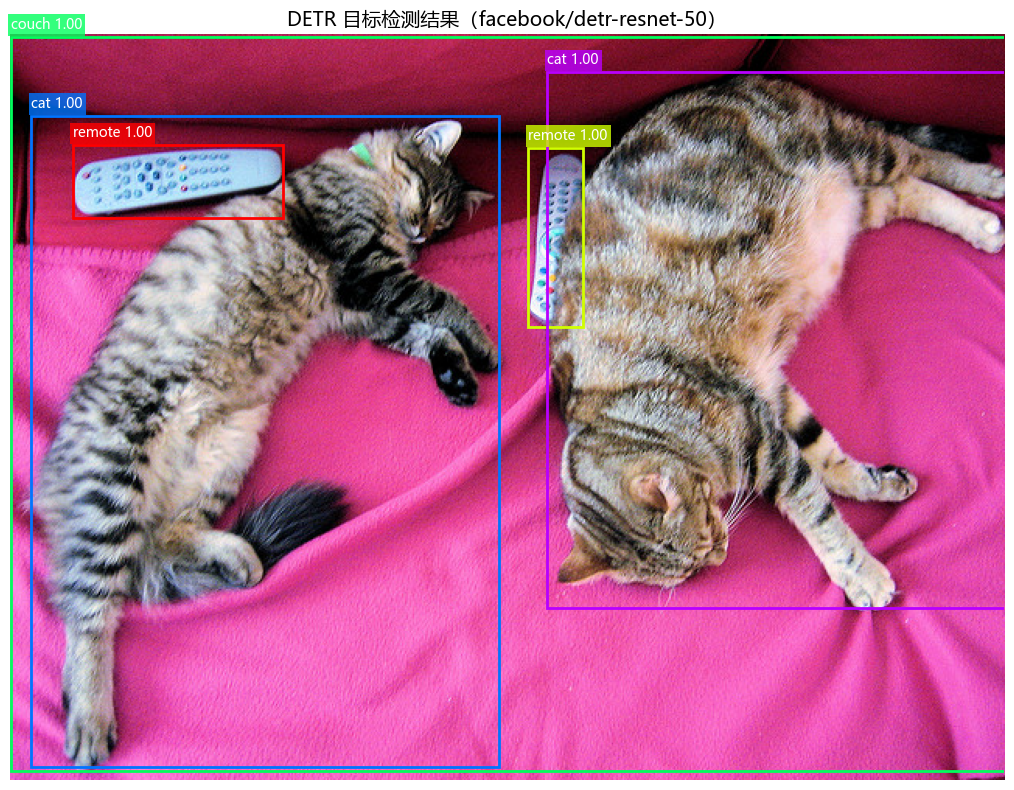

In [3]:
# ─── 中文字体配置 ────────────────────────────────────────────────────────────────
# Matplotlib 默认字体 DejaVu Sans 不含 CJK 字形，在标题/标签中使用中文会出现方块或警告
# 在 Windows 上将字体切换为微软雅黑（Microsoft YaHei），该字体内置于系统，无需额外安装
# rcParams["font.sans-serif"]: List[str]，无衬线字体候选列表，Matplotlib 按顺序寻找可用字体
# rcParams["axes.unicode_minus"]: bool，设为 False 以避免负号被渲染为方块（与中文字体兼容问题）
import matplotlib
matplotlib.rcParams["font.sans-serif"] = ["Microsoft YaHei", "SimHei", "DejaVu Sans"]  # 优先微软雅黑
matplotlib.rcParams["axes.unicode_minus"] = False  # 正确显示坐标轴负号

# ─── 后处理：将模型输出转换为可读检测结果 ────────────────────────────────────────
# image.size 返回 (W, H)，[::-1] 翻转为 (H, W)，满足 target_sizes 的格式要求
# torch.tensor: 包装为形状 (1, 2) 的 int64 张量，对应 batch 中第 0 张图的原始分辨率
target_sizes = torch.tensor([image.size[::-1]])  # 形状 (1, 2)，值示例 [480, 640]

# post_process_object_detection 内部步骤：
#   1. 对 logits 做 softmax，得到各 query 对所有类别的概率分布
#   2. 取每个 query 置信度最高的类别及其分数
#   3. 过滤掉置信度 <= threshold 的 query
#   4. 将归一化框坐标 (cx, cy, w, h) 转换为绝对像素坐标 (x1, y1, x2, y2)
# threshold=0.9: 仅保留置信度 > 0.9 的目标（可降低至 0.5 以获取更多检测结果）
# 返回值: List[Dict]，长度=batch_size；每个 Dict 包含：
#   - "scores": Tensor，形状 (n_det,)，各目标置信度，float32，取值 (threshold, 1.0]
#   - "labels": Tensor，形状 (n_det,)，各目标 COCO 类别 id，int64
#   - "boxes":  Tensor，形状 (n_det, 4)，绝对像素坐标 (x1, y1, x2, y2)，float32
results = processor.post_process_object_detection(
    outputs, target_sizes=target_sizes, threshold=0.9
)[0]  # 取 batch 第 0 张图的结果，类型 Dict[str, Tensor]

# ─── 控制台打印检测结果 ────────────────────────────────────────────────────────────
print(f"共检测到 {len(results['scores'])} 个目标（置信度阈值=0.9）：\n")
for score, label, box in zip(results["scores"], results["labels"], results["boxes"]):
    # model.config.id2label: Dict[int, str]，将 COCO 类别 id 映射为类别名称
    class_name = model.config.id2label[label.item()]        # label.item() 将 0 维张量转为 Python int
    confidence = round(score.item(), 3)                     # score.item() 转为 Python float，保留 3 位小数
    coords = [round(c, 1) for c in box.tolist()]           # box.tolist() 转为 List[float]，[x1,y1,x2,y2]
    print(f"  {class_name:<15} 置信度: {confidence:<6}  框: {coords}")

# ─── 可视化：在原图上绘制检测框与标签 ────────────────────────────────────────────
fig, ax = plt.subplots(1, 1, figsize=(12, 8))  # 创建 12×8 英寸画布，ax 为 Axes 对象
ax.imshow(image)                                # 将 PIL 图像渲染到坐标轴，自动解析 RGB 通道

# 使用 plt.cm.hsv 色彩映射为不同目标分配不同颜色
# len(results["scores"]): int，检测到的目标数量
n_det = len(results["scores"])                                              # int，本次检测到的目标总数
colors = plt.cm.hsv([i / max(n_det, 1) for i in range(n_det)])             # List，每个元素为 RGBA 颜色元组

for idx, (score, label, box) in enumerate(
    zip(results["scores"], results["labels"], results["boxes"])
):
    x1, y1, x2, y2 = box.tolist()              # 解包四个角点坐标，均为绝对像素值（float）
    box_w = x2 - x1                             # 边界框宽度（像素）
    box_h = y2 - y1                             # 边界框高度（像素）
    class_name = model.config.id2label[label.item()]  # str，类别名称，如 "cat"、"person"
    color = colors[idx]                         # 当前目标对应的 RGBA 颜色元组

    # patches.Rectangle: 构造矩形 patch
    # (x1, y1): 左上角坐标；box_w, box_h: 宽高；linewidth: 线条宽度（磅）
    # edgecolor=color: 使用该目标专属颜色；facecolor="none": 透明填充（不遮挡图像内容）
    rect = patches.Rectangle(
        (x1, y1), box_w, box_h,
        linewidth=2, edgecolor=color, facecolor="none"
    )
    ax.add_patch(rect)   # 将矩形 patch 注册到 Axes，绘制时才实际渲染

    # ax.text: 在边界框左上角上方绘制文本标签
    # (x1, y1 - 5): 文本起始坐标，y1-5 使标签位于框上方 5 像素处
    # fontsize=10: 字体大小；color="white": 字体颜色
    # bbox.facecolor=color: 标签背景使用与边框相同的颜色，便于区分不同目标
    ax.text(
        x1, y1 - 5,
        f"{class_name} {score:.2f}",
        fontsize=10, color="white",
        bbox=dict(facecolor=color, alpha=0.8, pad=2, edgecolor="none")
    )

ax.axis("off")                                                          # 隐藏坐标轴刻度与边框线
plt.title("DETR 目标检测结果（facebook/detr-resnet-50）", fontsize=14)  # 设置图标题
plt.tight_layout()                                                      # 自动调整布局，防止内容被裁剪
plt.show()                                                              # 渲染并在 notebook 中显示